# Objectif du notebook 

Date de création : 12/01/2026

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")

In [3]:
sys.path.append(project_root)

# Chargement des temps d'émissions de la source pointés par Timothée M. 

In [4]:
fname = "emissions_source_12012026.xlsx"
fpath = os.path.join(root_groix_metadata, fname)

df_emission_src = pd.read_excel(fpath, sheet_name="Sheet1")

In [5]:
df_emission_src

,Date,Time UTC (non synchro),Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),Nrepeat,Trepeat (s),Vc carte (V),Gain ampli,File,Initial samples,Initial timestamp UTC (synchro),Comment
0,2025-10-14,08:50:04,5,trailed,14,1.70,sinus,600,600,1,10,4,1.0,5,channelA_2025-10-14_08-50-04.wav,"[19272847, 19528847, 19784847, 20040847, 20296...",NaN,not seen on DAS
1,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,5,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[49962471, 50602471, 51242471, 51882471, 52522...",NaN,not seen on DAS
2,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,10,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[65466315, 66159101, 66857251, 67575906, 68308...",NaN,"not seen on DAS, warning repetitions not regular"
3,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,600,600,5,10,10,2.0,5,channelA_2025-10-14_09-21-08.wav,"[25536251, 26176251, 26816251, 27456251, 28096...",NaN,NaN
4,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,615,615,5,10,10,4.0,5,channelA_2025-10-14_09-21-08.wav,"[81033224, 81673224, 82313224, 82953224, 83593...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,2025-10-16,14:27:20,1S,fixed,8,1.35,sinus,625,625,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[187486816, 188126816, 188766816, 189406816, 1...",NaN,NaN
165,2025-10-16,14:29:04,1S,fixed,8,1.35,sinus,225,225,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[194092678, 194732678, 195372678, 196012678, 1...",NaN,NaN
166,2025-10-16,14:30:51,1S,fixed,8,1.35,sinus,125,125,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[200991168, 201631168, 202271168, 202911168, 2...",NaN,NaN
167,2025-10-16,14:33:19,1S,fixed,8,1.35,chirp,80,1000,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[210334594, 210974594, 211614594, 212254594, 2...",NaN,NaN


In [6]:
# Form a datetime series from the Date and Time UTC columns
date = df_emission_src["Date"]
time = df_emission_src["Time UTC (non synchro)"]
# Datetime serie from date and time 
start_datetime = pd.to_datetime(date.astype(str) + " " + time.astype(str), format="%Y-%m-%d %H:%M:%S")

# Store in the dataframe
df_emission_src["Datetime"] = start_datetime

In [7]:
start_datetime

0     2025-10-14 08:50:04
1     2025-10-14 08:50:04
2     2025-10-14 08:50:04
3     2025-10-14 09:21:08
4     2025-10-14 09:21:08
              ...        
164   2025-10-16 14:27:20
165   2025-10-16 14:29:04
166   2025-10-16 14:30:51
167   2025-10-16 14:33:19
168   2025-10-16 14:37:47
Length: 169, dtype: datetime64[ns]

In [8]:
usefull_props = df_emission_src.columns.tolist()[2:-4]  # Exclude first two and last four columns
usefull_props.remove("Nrepeat")  # Remove Nrepeat
usefull_props.extend(["Datetime"])  # Add Datetime
usefull_data = {prop: [] for prop in usefull_props}
usefull_data["Start sample"] = []

# Loop over each line in the emission source dataframe
for idx in df_emission_src.index:
    line = df_emission_src.loc[idx]

    # Get number of single emissions
    apriori_n_single_emissions = line["Nrepeat"]

    # Store initial samples
    init_samp = line["Initial samples"]
    if isinstance(init_samp, str):
        init_samp = init_samp.split("[")[1].split("]")[0] # Remove opening and closing bracket 
        init_samp = [int(s.strip()) for s in init_samp.split(",")]      # Transform into int list
        # Update number of single emissions
        n_single_emissions = len(init_samp)     # Number of detected emissions

        # if len(init_samp) != n_single_emissions:
        #     print(idx, len(init_samp), n_single_emissions)
    elif isinstance(init_samp, float) and np.isnan(init_samp):
        # print(idx, line)
        init_samp = [np.nan] * apriori_n_single_emissions       # If the line is empty we use apriori number of emissions
    else:
        print(f"Error reading line {idx}")
        break

    # Store all usefull informations
    for prop in usefull_props:
        usefull_data[prop].extend([line[prop]] * n_single_emissions)

    usefull_data["Start sample"].extend(
        init_samp
    )


# print(init_samp)

props_dtype = {
    "Point": str,
    "Source": str,
    "Signal": str,
    "File": str,
    "Longueur filée (m)": str,      # Line with "ascending to 2m"
    "Hydro distance (m)": np.float32,
    "Frequency min (Hz)": np.float32,
    "Frequency max (Hz)": np.float32,
    "Duration (s)": np.float32,
    "Trepeat (s)": np.float32,
    "Vc carte (V)": np.float32,
    "Gain ampli": np.float32,
}

# Convert each property to the correct dtype
for prop in usefull_data.keys():
    usefull_data[prop] = pd.Series(usefull_data[prop], dtype=props_dtype.get(prop, object))

# Create final dataframe
df = pd.DataFrame(usefull_data)
# Convert Datetime back to datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])
# Rename Datetime column for clarity 
df = df.rename(columns={"Datetime": "File start datetime"})

# Drop lines with nan in Start sample
df = df.dropna(subset=["Start sample"]).reset_index(drop=True)

In [9]:
# Convert Start sample into UTC time
fs = 64000 # D'après le rapport de campagne 
Ts = 1 / fs

start_delta_time = df["Start sample"] * Ts  # in seconds
start_time_utc = df["File start datetime"] + pd.to_timedelta(start_delta_time, unit="s")

In [10]:
df["Emission datetime"] = start_time_utc

In [11]:
# Reorganize a bit for clarity : Emission datetime -> first column 
cols = df.columns.tolist()
cols.remove("Emission datetime")
cols = ["Emission datetime"] + cols
df = df[cols]

df.isna().sum()

Emission datetime         0
Point                  1117
Source                    0
Longueur filée (m)        0
Hydro distance (m)        0
Signal                    0
Frequency min (Hz)        0
Frequency max (Hz)        0
Duration (s)              0
Trepeat (s)               0
Vc carte (V)              0
Gain ampli                0
File                      0
File start datetime       0
Start sample              0
dtype: int64

# Association des émissions à la position de la source 

In [12]:
# Load datasets
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

In [13]:
# First approach : Nearest neighbor in time for GPS
gps_emission_time = ds_gps.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude GPS"] = gps_emission_time["lat"].values
df["Emission longitude GPS"] = gps_emission_time["lon"].values
df["Emission E GPS"] = gps_emission_time["e"].values
df["Emission N GPS"] = gps_emission_time["n"].values
df["Emission U GPS"] = gps_emission_time["u"].values

In [15]:
# First approach : Nearest neighbor in time for GPS
mmsi_jules = 226916000
ds_ais = ds_ais.sel(mmsi=mmsi_jules)
ais_emission_time = ds_ais.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude AIS"] = ais_emission_time["lat"].values
df["Emission longitude AIS"] = ais_emission_time["lon"].values
df["Emission E AIS"] = ais_emission_time["e"].values
df["Emission N AIS"] = ais_emission_time["n"].values
df["Emission U AIS"] = ais_emission_time["u"].values

In [16]:
df

,Emission datetime,Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),Trepeat (s),...,Emission latitude GPS,Emission longitude GPS,Emission E GPS,Emission N GPS,Emission U GPS,Emission latitude AIS,Emission longitude AIS,Emission E AIS,Emission N AIS,Emission U AIS
0,2025-10-14 08:55:05.138234375,5,trailed,14,1.70,sinus,600.0,600.0,1.0,4.0,...,47.664747,-3.426608,2820.966721,-490.712365,-20.048594,47.664825,-3.426578,2823.190667,-481.927742,-20.048906
1,2025-10-14 08:55:09.138234375,5,trailed,14,1.70,sinus,600.0,600.0,1.0,4.0,...,47.664747,-3.426608,2820.966721,-490.712365,-20.048594,47.664825,-3.426578,2823.190667,-481.927742,-20.048906
2,2025-10-14 08:55:13.138234375,5,trailed,14,1.70,sinus,600.0,600.0,1.0,4.0,...,47.664747,-3.426608,2820.966721,-490.712365,-20.048594,47.664825,-3.426578,2823.190667,-481.927742,-20.048906
3,2025-10-14 08:55:17.138234375,5,trailed,14,1.70,sinus,600.0,600.0,1.0,4.0,...,47.664791,-3.426691,2814.730407,-485.786224,-20.045467,47.664906,-3.426775,2808.408906,-472.901202,-20.041716
4,2025-10-14 08:55:21.138234375,5,trailed,14,1.70,sinus,600.0,600.0,1.0,4.0,...,47.664791,-3.426691,2814.730407,-485.786224,-20.045467,47.664906,-3.426775,2808.408906,-472.901202,-20.041716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2707,2025-10-16 15:46:48.083187500,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,47.742416,-3.346872,8796.672236,8150.890070,-30.676527
2708,2025-10-16 15:46:50.083187500,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,47.742416,-3.346872,8796.672236,8150.890070,-30.676527
2709,2025-10-16 15:46:52.083187500,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,47.742416,-3.346872,8796.672236,8150.890070,-30.676527
2710,2025-10-16 15:46:54.083187500,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,47.742416,-3.346872,8796.672236,8150.890070,-30.676527


Text(0, 0.5, 'Latitude')

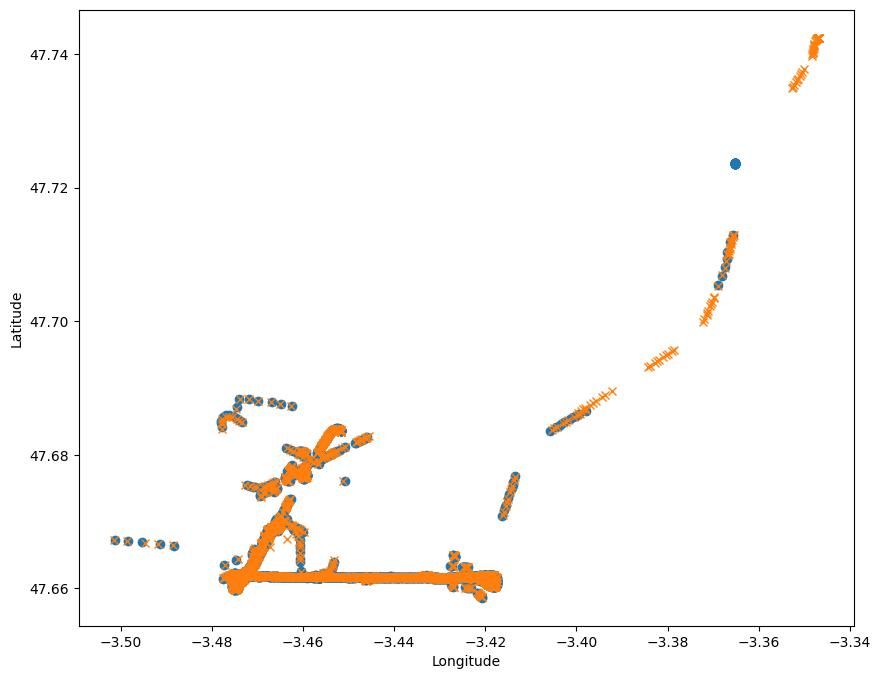

In [17]:
# Plot 
plt.figure(figsize=(10, 8))
plt.plot(df["Emission longitude GPS"], df["Emission latitude GPS"], 'o', label="GPS Emission positions")
plt.plot(df["Emission longitude AIS"], df["Emission latitude AIS"], 'x', label="AIS Emission positions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")